# INTRODUCCIÓN

Este Notebook es un análisis de una tienda de mayoreo, la cual contiene infromación de múltiples productos de múltiples fabricantes (Panel Data)

Se estructura en el siguiente orden:


1. Limpieza de Datos
2. Agrupado mensual
3. Estadística Descriptiva
4. Market Share por Fabricante
5. Análisis Mensual de últimos 12 meses
6. Matriz de Covarianza y Correlación histórico de productos top
7. Análisis temporal por Fabricante
8. Análisis Mensual de Fabricante 1
9. Modelo de regresión lineal simple
10. Modelos logarítmicos de regresión múltiple

#Inicialización de Database

In [80]:
#Librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [81]:
#Inicialización de Dataset
df = pd.read_excel("/content/DATA_VENTAS.xlsx")

#Descripción incial
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3296 entries, 0 to 3295
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CORTE                    3296 non-null   object        
 1   FABRICANTE               3296 non-null   object        
 2   ID                       3296 non-null   object        
 3   PRODUCTO                 3296 non-null   object        
 4   AÑO1                     3296 non-null   int64         
 5   SEMANA                   3296 non-null   int64         
 6   MES                      3296 non-null   int64         
 7   FECHAW                   3296 non-null   datetime64[ns]
 8   FECHAM                   3296 non-null   datetime64[ns]
 9   VENTA_VALOR              3296 non-null   float64       
 10  LITROS                   3296 non-null   int64         
 11  PRECIO_UNITARIO_LITRO    3293 non-null   float64       
 12  PAQUETES                 3296 non-

A primera vista del dataset, se observa que contiene 3,296 filas y 15 columnas. La mayoría de las columnas están completas, a excepción de "PRECIO_UNITARIO_LITRO", la cual tiene 3 valores nulos.

In [82]:
summary_weekly = (
    df.groupby('FABRICANTE')
    .agg(
        ventas=('VENTA_VALOR', 'sum'),
        litros=('LITROS', 'sum'),
        productos=('ID', 'nunique')
    )
    .sort_values('ventas', ascending=False)
)

summary_weekly

,ventas,litros,productos
FABRICANTE,,,
FAB1,9.660932e+08,47584872,8
FAB3,6.913222e+08,32931156,3
FAB2,4.497629e+08,23032956,9
FAB5,1.563710e+08,8098860,3
FAB6,2.941226e+07,1893240,3


En el resumen agrupado por fabricante, se puede observar que el fabricante con mayor cantidad de venta y de litros es el 1, con una cantidad de 8 productos. Este es seguido por el fabricante 3 que solo contiene 3 litros.


Esto da una visualización inicial sobre los fabricantes más grandes en este mercado. También la tabla aporta en realizar la comparación de ventas y litros tras hacer la agrupación mensual.

In [83]:
#Columnas con valores nulos
df[df['PRECIO_UNITARIO_LITRO'].isnull()]

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1309,TN,FAB1,Leche Clasica Semi 1 L,FAB1_Leche Clasica Semi 1 L,2024,16,4,2024-04-15,2024-04-01,0.0,192,NaN,16,NaN,12
1659,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2025,4,1,2025-01-20,2025-01-01,-268.0,0,NaN,0,NaN,12
3268,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,17,4,2025-04-21,2025-04-01,0.0,0,NaN,0,NaN,12


Observando las columnas, se identifica que son de 3 productos distintos y tienen vacíos en el precio unitario de litro ya que este se calcula con las columnas de Venta del producto y Litros que se vendieron.

Se calcula de la siguiente forma:

$\frac{Venta}{Litros}$

Sabiendo esto, al tener que calcularlo y teniendo valores con 0, causa un error y no es posible determinarlo.

En este caso, se mantendrán en el dataset para no perder información y no será afectada, ya que se realizará un análisis a nivel mensual y se agruparán los datos.

In [84]:
df.groupby('PRODUCTO')['ID'].nunique().sort_values(ascending=False).head(50)

,ID
PRODUCTO,
FAB1_1L Sel Des Deslactosada,1
FAB1_1L Sele En Selecta Entera,1
FAB1_Leche Clasica Deslactosada 1 L,1
FAB1_Leche Clasica Deslactosada Light 1 L,1
FAB1_Leche Clasica Entera 1 L,1
FAB1_Leche Clasica Extra Deslactosada 1 L,1
FAB1_Leche Clasica Light 1 L,1
FAB1_Leche Clasica Semi 1 L,1
FAB2_ 100 70+30,1


In [85]:
df.groupby('ID')['PRODUCTO'].nunique().sort_values(ascending=False).head(50)

,PRODUCTO
ID,
100 70+30,1
100 Low C Arb,1
Des Light Deslactosada Light 1L,1
Deslac Deslactosada 1 L,1
ENTERA 1.5LT 10PZ,1
Entera Entera 1 L,1
Light Light 1L,1
Semi Semi Descremada 1L,1
12 1L Leche Y Pan Light,1


Es importante tener en cuenta que puede existir duplicado en ambos sentidos, por lo que se analiza de ambos lados relación entre ID-Producto, así como relación Producto-ID.

Para ambos lados se puede observar que no existe una duplicidad.

Ahora, se buscará analizar a nivel de granularidad de Fabricante, ID, Producto y Concatenado Semanal con el propósito de que no exista un duplicado de semanas o un error a mayor profundidad que en el agrupado mensual ya no sea posible visualizar.

In [86]:
df[df.duplicated(
    subset=['FECHAW', 'FABRICANTE', 'ID'],
    keep=False
)].sort_values(
    ['FABRICANTE', 'ID', 'FECHAW']
).head(6)

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1629,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,211303.67,9336,22.633212,778,271.598548,12
1630,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,8397.00,396,21.204545,33,254.454545,12
1631,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,210346.78,10116,20.793474,843,249.521684,12
1632,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,80793.00,3924,20.589450,327,247.073394,12
1633,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,40552.91,1884,21.524899,157,258.298790,12
1634,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,161971.97,7716,20.991702,643,251.900420,12


Se ha identificado registros dobles para una misma combinación de fabricante, producto y semana. Revisando los valores, no parece ser un duplicado ya que no son dos registros con los mismos valores.

Ya que la variable de venta y volumen son acumulables y se realizará posteriormente para un agrupado mensual, los registros se van a mantener.

# Agrupado Mensual

Una vez realizada la limpieza y transformación de datos, se busca hacer un agrupado a nivel mensual que permita hacer un análisis más generalizado.

In [87]:
monthly = (
    df.groupby(
        [
            'CORTE',
            'FABRICANTE',
            'ID',
            'PRODUCTO',
            'AÑO1',
            'MES',
            'FECHAM'
        ],
        as_index=False
    )
    .agg({
        'VENTA_VALOR': 'sum',
        'LITROS': 'sum',
        'PAQUETES': 'sum',
        'UNIDADES_EN_PAQUETE': 'first'
    })
)

monthly['PPU_Litro'] = (
    monthly['VENTA_VALOR'] / monthly['LITROS']
)

monthly['PPU_Paquete'] = (
    monthly['VENTA_VALOR'] / monthly['PAQUETES']
)

Tras realizar el agrupado mensual de ventas y unidades a nivel ID, Producto, Fabricante y Fecha Mensual, se recalcula el precio unitario por litro y por paquete. Esto se debe a que, se busca obtener el valor de precio unitario por litro de forma mensual, por lo que hacer un promedio de los precios obtenidos anteriormente no sería adecuado.



In [88]:
monthly.duplicated(
    subset=['FABRICANTE', 'ID', 'FECHAM', 'PRODUCTO']
).sum()

np.int64(0)

In [89]:
monthly.isnull().sum()

,0
CORTE,0
FABRICANTE,0
ID,0
PRODUCTO,0
AÑO1,0
MES,0
FECHAM,0
VENTA_VALOR,0
LITROS,0
PAQUETES,0


Al hacer el agrupado mensual, se ha desaparecido los valores vacíos y esto es adecuado ya que se recalculan los precios unitarios tanto de litro como de unidad de forma mensual, por lo que las semanas que daban un problema ya fueron tratados y se comprueba que no existen valores vacíos.

También se observa que el empalme de datos del producto de Fabricante 2 han sido agrupados de manera correcta y que ya no existe el error de información.


Una vez realizado esto, se busca entender los datos utilizando la estadística descriptiva. Esto nos permite entender los rangos de datos, si existe algún sesgo o valor atípico en los datos.

Cabe aclarar que es un agrupado de todos los productos y no desglosado, esto es para darse una idea general del comportamiento general de la categoría.

# Estadística Descriptiva

In [90]:
monthly[
    ['VENTA_VALOR', 'LITROS', 'PAQUETES',
     'PPU_Litro', 'PPU_Paquete']
].describe()

,VENTA_VALOR,LITROS,PAQUETES,PPU_Litro,PPU_Paquete
count,7.100000e+02,710.000000,710.000000,710.000000,710.000000
mean,3.229523e+06,159917.019718,13324.498592,20.771895,249.437445
std,2.881898e+06,144507.543090,12043.748466,3.138157,37.797689
min,-3.278010e+03,-144.000000,-12.000000,1.303922,15.647059
25%,1.157783e+06,57192.000000,4759.250000,18.937465,227.249583
50%,2.063759e+06,98820.000000,8235.000000,20.416099,245.374141
75%,4.761391e+06,243660.000000,20305.000000,22.402781,269.068687
max,1.588330e+07,787368.000000,65614.000000,32.540592,390.487104


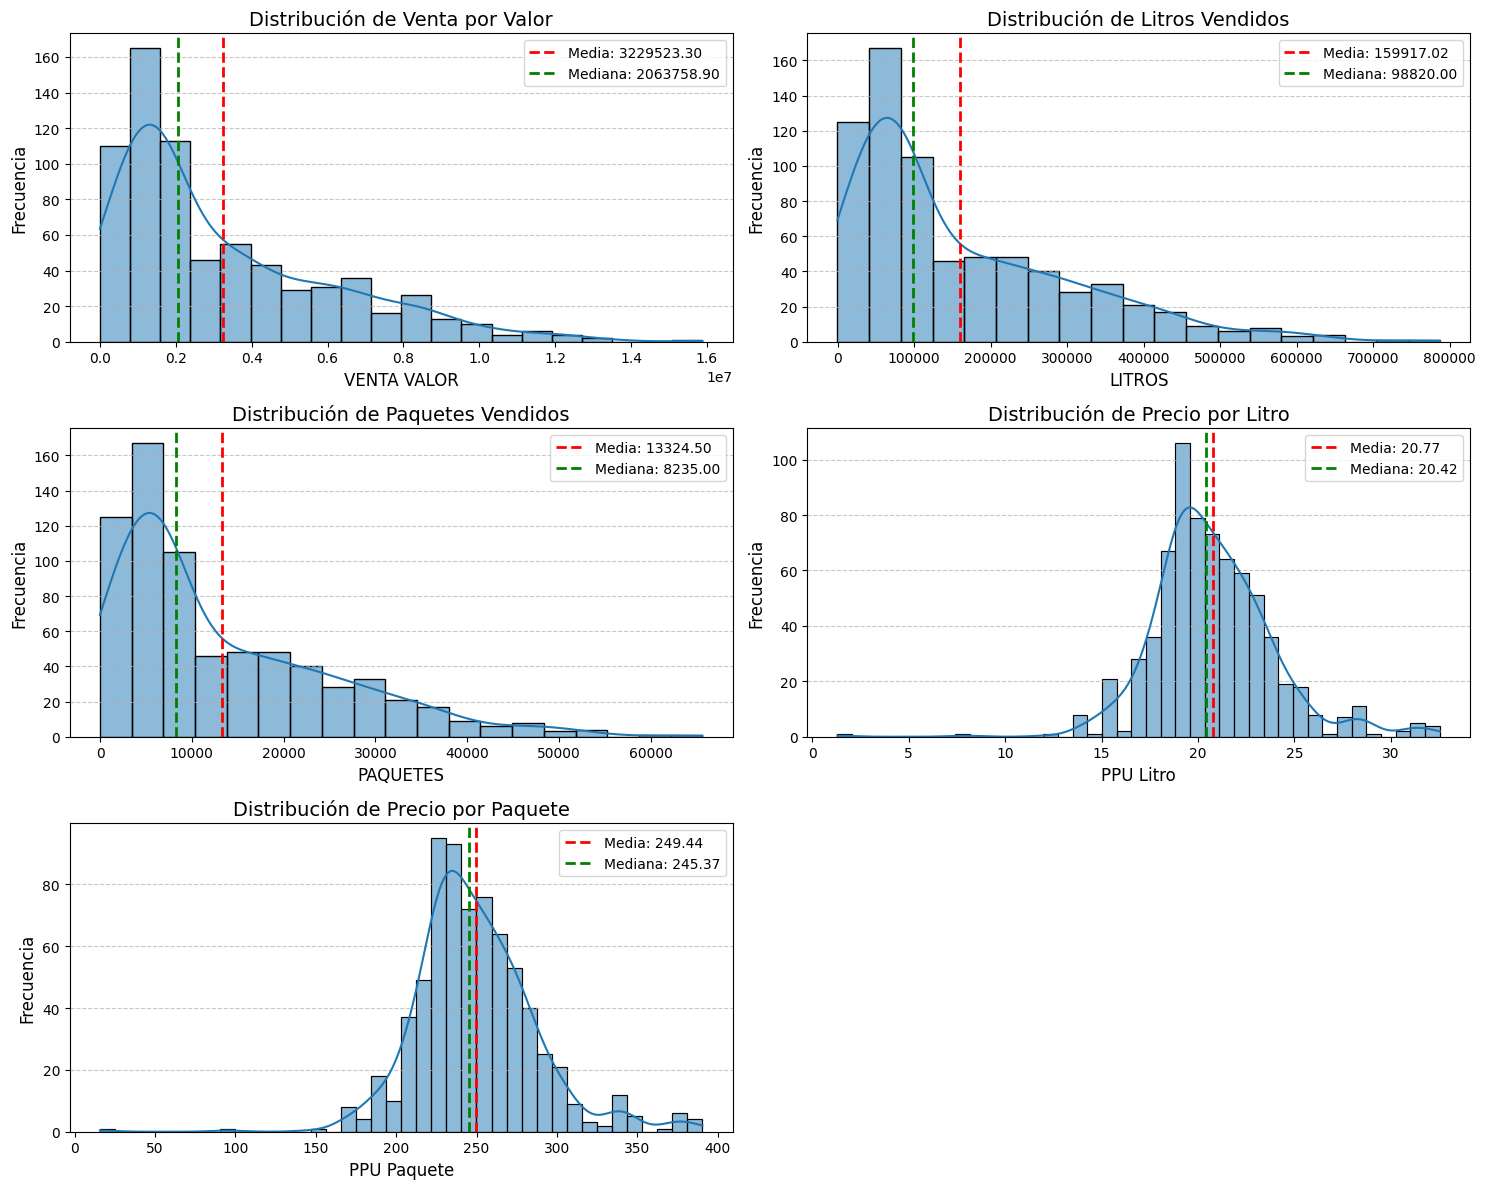

In [91]:
columns_to_plot = [
    'VENTA_VALOR', 'LITROS', 'PAQUETES',
    'PPU_Litro', 'PPU_Paquete'
]

plot_titles = {
    'VENTA_VALOR': 'Distribución de Venta por Valor',
    'LITROS': 'Distribución de Litros Vendidos',
    'PAQUETES': 'Distribución de Paquetes Vendidos',
    'PPU_Litro': 'Distribución de Precio por Litro',
    'PPU_Paquete': 'Distribución de Precio por Paquete'
}

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(15, 12)
)

axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(monthly[col], kde=True, ax=axes[i])
    axes[i].set_title(plot_titles[col], fontsize=14)
    axes[i].set_xlabel(col.replace('_', ' '), fontsize=12)
    axes[i].set_ylabel('Frecuencia', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    mean_val = monthly[col].mean()
    median_val = monthly[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {median_val:.2f}')
    axes[i].legend()

if len(columns_to_plot) < len(axes):
    for j in range(len(columns_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observando la estadística descriptiva general e histogramas, Se pueden tener las siguientes observaciones:
* Para las ventas, su promedio está ligeramente arriba de la mediana y su desviación estándar es considerable. El valor máximo se diferencia mucho y eso puede ser lo que provoca la diferencia entre la mediana y la media.
* En el caso de litros, su deviación se podría considerar algo grande y se podría interpretar que si existe mucha variabilidad entre la venta de litros entre cada uno de los productos. También existe el caso en que la media está arriba de la mediana.
* La venta de paquetes tiene una distribución muy similar a la de ventas, lo cual podría en el negocio tiene sentido debido a que si uno tiene mucha venta es porque se han vendido muchos paquetes.
* La columna de PPU por litro y PPU por paquete tienen media y mediana bastante cercanas. Observando ambas colas del histograma, abundan más los valores atípicos positivos.
* En el caso de Venta, Litros y Unidades, se observa que en el mínimo hay valores negativos. Estos se tomarán en cuenta como devoluciones que se realizaron.

In [92]:
fab_summary = (
    monthly.groupby('FABRICANTE')
    .agg(
        ventas=('VENTA_VALOR', 'sum'),
        litros=('LITROS', 'sum'),
        productos=('ID', 'nunique')
    )
    .sort_values('ventas', ascending=False)
)

fab_summary

,ventas,litros,productos
FABRICANTE,,,
FAB1,9.660932e+08,47584872,8
FAB3,6.913222e+08,32931156,3
FAB2,4.497629e+08,23032956,9
FAB5,1.563710e+08,8098860,3
FAB6,2.941226e+07,1893240,3


In [93]:
venta_semanal = df['VENTA_VALOR'].sum()
unidades_semanal = df['LITROS'].sum()
venta_mensual = monthly['VENTA_VALOR'].sum()
unidades_mensual = monthly['LITROS'].sum()

print(f"Venta Semanal: {venta_semanal}")
print(f"Unidades Semanales: {unidades_semanal}")
print(f"Venta Mensual: {venta_mensual}")
print(f"Unidades Mensual: {unidades_mensual}")

Venta Semanal: 2292961541.85
Unidades Semanales: 113541084
Venta Mensual: 2292961541.8500004
Unidades Mensual: 113541084


Analizando la tabla de ventas y litros por fabricante en todo el histórico, se observa que el fabricante 1 es el que contiene históricamente la mayor cantidad de ventas, seguido por el fabricante 3, lo cual concuerda con lo mencionado en la agrupación semanal que se realizó al comienzo del reporte. También se analiza que no hubo variación en venta, litro o producto al hacer la agrupación mensual respecto a la base de datos original.

#Market Share por Fabricante (Histórico)

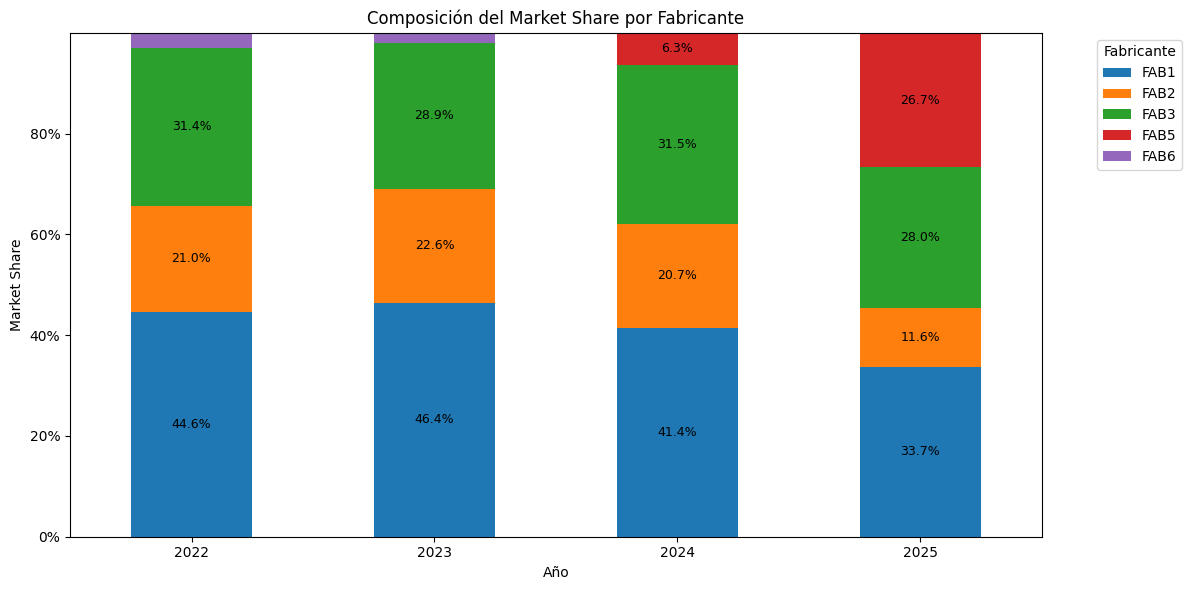

In [94]:
annual_sales = (
    monthly.groupby(['AÑO1', 'FABRICANTE'])
    ['VENTA_VALOR']
    .sum()
    .reset_index()
)

annual_sales['MARKET_SHARE'] = (
    annual_sales['VENTA_VALOR'] /
    annual_sales.groupby('AÑO1')['VENTA_VALOR']
    .transform('sum')
)

share_pivot = annual_sales.pivot(
    index='AÑO1',
    columns='FABRICANTE',
    values='MARKET_SHARE'
)

ax = share_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.title('Composición del Market Share por Fabricante')
plt.xlabel('Año')
plt.ylabel('Market Share')
plt.legend(
    title='Fabricante',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=0)

# Agregar porcentajes dentro de cada segmento
for container in ax.containers:
    labels = [
        f'{bar.get_height() * 100:.1f}%'
        if bar.get_height() > 0.03 else ''
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Observando el comportamiento del mercado, se interpreta que los principales competidores son el fabricnate 1,2 y 3. Tras 2024 y la llegada de Fabricante 5, los fabricantes principales comienzan a perder market share, especialmente el fabricante 2.

# Market Share en los últimos 12 meses

In [95]:
ultima_fecha = monthly['FECHAM'].max()
fecha_inicio = ultima_fecha - pd.DateOffset(months=11)

monthly_l12m = monthly[
    (monthly['FECHAM'] >= fecha_inicio) &
    (monthly['FECHAM'] <= ultima_fecha)
].copy()

fab_sales = (
    monthly_l12m
    .groupby(['FABRICANTE'])['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)
fab_share = (
    fab_sales /
    fab_sales.sum()
)

product_sales = (
    monthly_l12m
    .groupby(['FABRICANTE','PRODUCTO'])['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)
product_share = (
    product_sales /
    product_sales.sum()
)

In [96]:

print("Market Share por Fabricante (últimos 12 meses)")
print(round(fab_share,2))
print("")

fab_share_cum = round(fab_share.cumsum(),2)

print("Market Share acumulado por producto (últimos 12 meses)")

print(fab_share_cum)

print("Market Share por producto (últimos 12 meses)")
print(round(product_share,2))
print("")

product_share_cum = round(product_share.cumsum(),2)

print("Market Share acumulado por producto (últimos 12 meses)")

print(product_share_cum)

Market Share por Fabricante (últimos 12 meses)
FABRICANTE
FAB1    0.36
FAB3    0.29
FAB5    0.22
FAB2    0.13
Name: VENTA_VALOR, dtype: float64

Market Share acumulado por producto (últimos 12 meses)
FABRICANTE
FAB1    0.36
FAB3    0.65
FAB5    0.87
FAB2    1.00
Name: VENTA_VALOR, dtype: float64
Market Share por producto (últimos 12 meses)
FABRICANTE  PRODUCTO                                 
FAB3        FAB3_1L  Ent Entera                          0.15
FAB1        FAB1_Leche Clasica Entera 1 L                0.12
            FAB1_Leche Clasica Deslactosada 1 L          0.12
FAB5        FAB5_Mm 12/1L Leche Ente Members Mark        0.11
FAB3        FAB3_1L  Desl Deslactosada                   0.11
FAB5        FAB5_Mm 12/1L Leche Desla Members Mark       0.10
FAB1        FAB1_Leche Clasica Deslactosada Light 1 L    0.06
FAB2        FAB2_ Deslac Deslactosada 1 L                0.04
            FAB2_12/1L  100 Proteina                     0.04
FAB1        FAB1_1L  Sele En Selecta Entera   

En los gráficos anteriores se puede ver el comportamiento tanto a nivel fabricante como a nivel producto de la tienda y el market share de los últimos 12 meses.

En el caso de market share a Nivel Fabricante, se puede observar que los 3 fabricantes principales son el fabricante 1,3 y 5. Estos conforman el 87% de market share.


Ahora, a Nivel Producto, se puede observar que los productos que conforman el 80% de market share en los últimos 12 meses son los siguientes:

1. FAB3_1L  Ent Entera                          0.15
2. FAB1_Leche Clasica Entera 1 L                0.12
3. FAB1_Leche Clasica Deslactosada 1 L          0.12
4. FAB5_Mm 12/1L Leche Ente Members Mark        0.11
5. FAB3_1L  Desl Deslactosada                   0.11
6. FAB5_Mm 12/1L Leche Desla Members Mark       0.10
7. FAB1_Leche Clasica Deslactosada Light 1 L    0.06
8. FAB2_ Deslac Deslactosada 1 L                0.04


El producto con el market share más alto es de 15%, siendo este del fabricante 3, Haciendo relación con el market share por fabricante, los fabricantes 3 y 5 son los directos competidores hacia el fabricante 1, ya que tiene casi la misma proporción de market share entre ellos. Los 3 fabricantes componen aproximadamente 88.4% del mercado en 2025. Es importante mencionar que el fabricante 3 y 5 contienen solo 3 productos y el fabricante 5 es la marca privada de la tienda.

# Correlación entre productos con mayor venta


Una vez analizados los productos con mayor market share del mercado, se buscaría hacer un análisis histórico con el precio de estos productos, para así intentar encontrar alguna relación entre estos que sea significativa y permita entender mejor la relación entre ellos en el mercado.

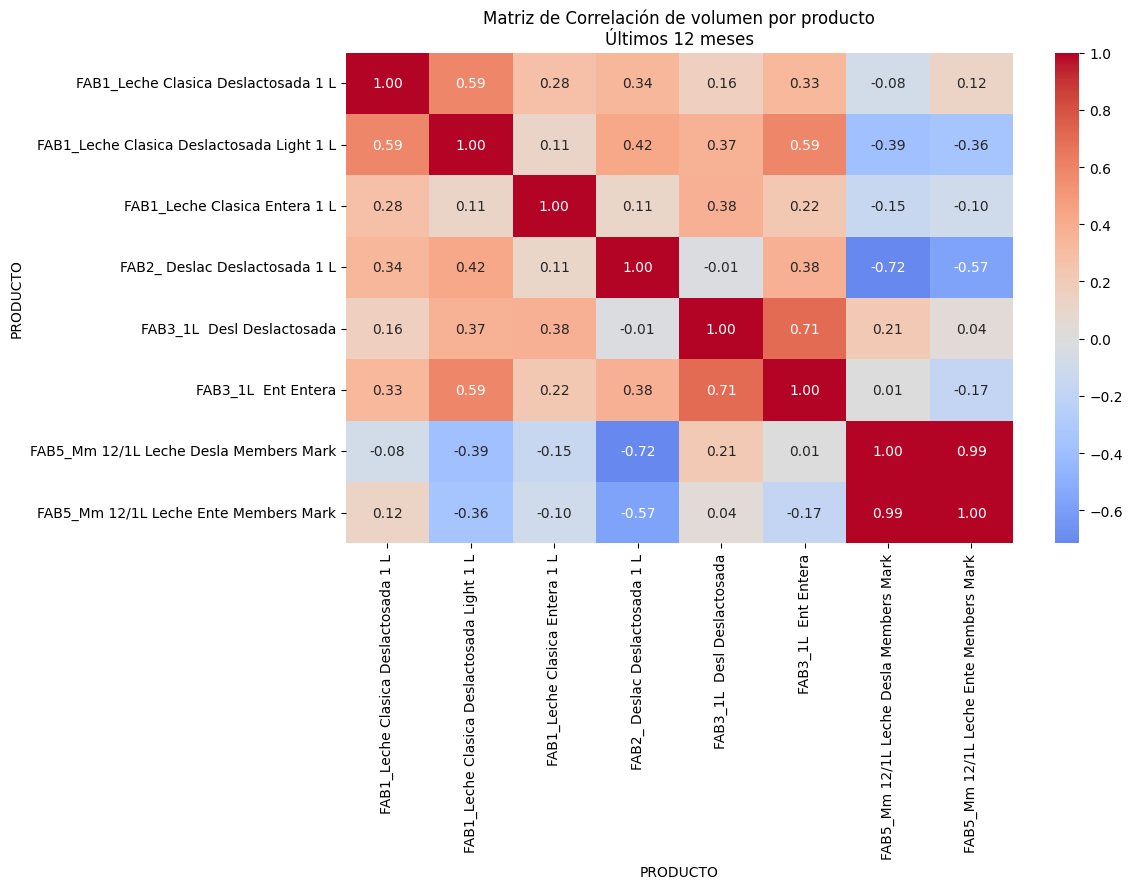

In [122]:
productos = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Entera 1 L',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB5_Mm 12/1L Leche Ente Members Mark',
    'FAB3_1L  Desl Deslactosada',
    'FAB5_Mm 12/1L Leche Desla Members Mark',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]



# Producto objetivo
target_product = 'FAB1_Leche Clasica Entera 1 L'

# Productos top a analizar
productos_corr = productos.copy()

# Asegurarnos de incluir el producto objetivo
if target_product not in productos_corr:
    productos_corr.append(target_product)

# Filtrar los productos seleccionados
corr_df = monthly[
    monthly['PRODUCTO'].isin(productos_corr)
].copy()

corr_df = corr_df.sort_values('FECHAM')

#Convertir a formato WIDE
precio_pivot = corr_df.pivot_table(
    index='FECHAM',
    columns='PRODUCTO',
    values='PPU_Litro',
    aggfunc='mean'
)

# Convertir a formato WIDE para volumen
volumen_pivot = corr_df.pivot_table(
    index='FECHAM',
    columns='PRODUCTO',
    values='LITROS',
    aggfunc='sum'
)

# Matriz de correlación entre volúmenes
correlacion_volumen = volumen_pivot.corr()




plt.figure(figsize=(12, 9))

sns.heatmap(
    correlacion_volumen,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de Correlación de volumen por producto\n'
    'Últimos 12 meses'
)

plt.tight_layout()
plt.show()

Analizando las matrices de correlación entre volumen, se puede observar principalmente la correlación inversamente proporcional entre productos de Fabricante 5 y 2. Esto da a indicar que cuando se aumenta la venta de producto de el fabricante 5, se disminuye la venta del fabricante 2. También es importante mencionar que es mayor la relación inversa entre el producto deslactosado de ambos fabricantes. Esto se puede intepretar que existe un intercmbio directo entre ellos. Se analizará más a fondo en el transcurso del reporte.

También se puede analizar que las muchas de las correlaciones más altas son entre productos del mismo fabricante, por lo que la venta de uno tiene un impacto efectivo en el otro.

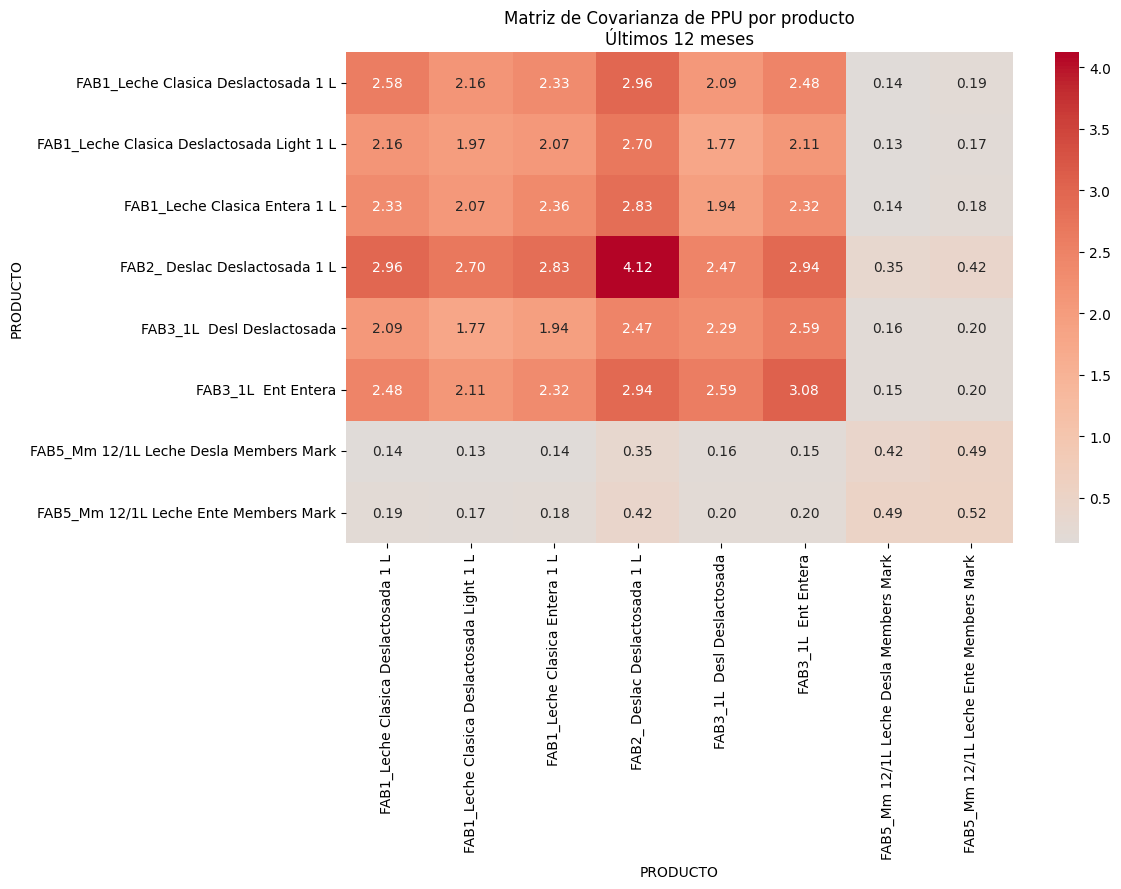

In [98]:
cov_precios = precio_pivot.cov()

plt.figure(figsize=(12, 9))

sns.heatmap(
    cov_precios,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de Covarianza de PPU por producto\n'
    'Últimos 12 meses'
)

plt.tight_layout()
plt.show()

Respecto a la covarianza, se puede observar que todos los productos muestran una relación positiva entre una y la otra.

El valor que más se destaca es la varianza de FAB2_Deslactosada, el cual muestra un valor de 4.12, esto muestra que este es muy disperso respecto a su promedio.También es el producto con mayor covarianza entre los precios de los demás productos. En conjunto, los precios mantienen una dispersión aproximada a 2, lo cual ayuda a entender que se mueven con una intensidad parecida. Observando la diagonal y la varianza de cada producto, se puede entender que la dispersión de los precios se explican en como se mueven de forma conjunta.

En el caso de Fabricante 5, se puede observar una baja relación, esto también se debe a que por defecto de la librería, se analiza por método de *Pairwise Deletion*, el cual al contener muchos vacíos (así como el caso de Fabricante 5 que tiene información desde Julio de 2024) pierde fuerza y convierte este valor en uno bajo. Esto se menciona para aclarar que no significa que no existe una relación entre los productos y los del fabricante 5, solo que el método estadístico no lo determina.

Este gráfico da un primer indicador hacia la matriz de correlación para analizar sobre el comportamiento de cada precio respecto al de otro producto.



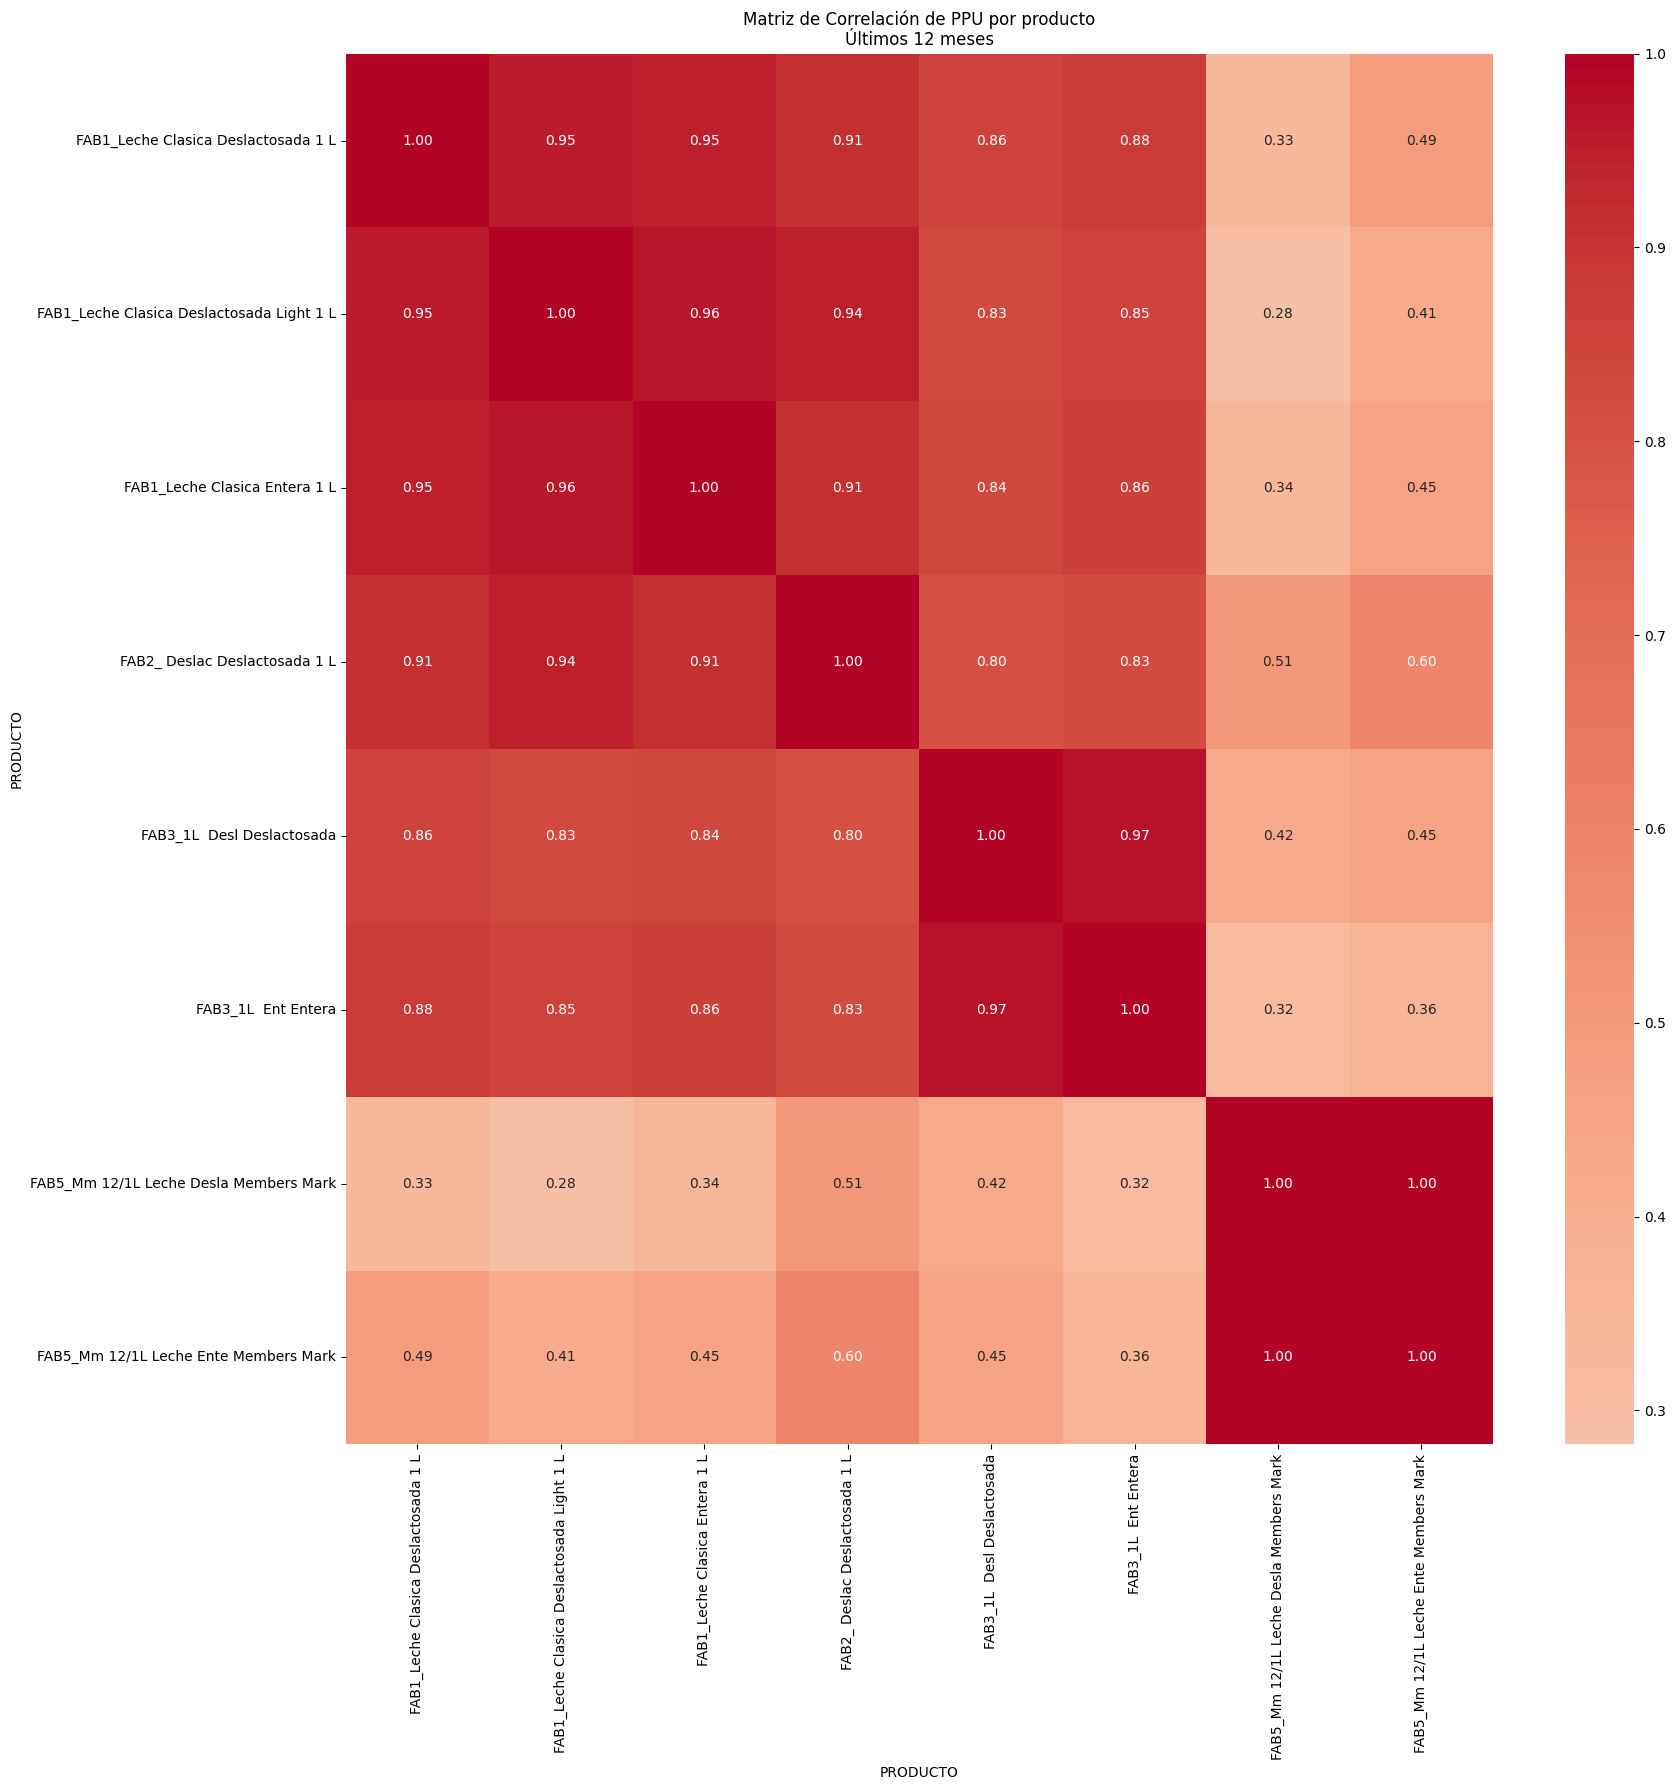

In [99]:
corr_precios = precio_pivot.corr()

corr_precios

plt.figure(figsize=(18, 18))
sns.heatmap(
    corr_precios,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de Correlación de PPU por producto\n'
    'Últimos 12 meses'
)

plt.tight_layout()
plt.show()



En la matriz de correlación se puede observar que toda la categoría tiene una relación alta de casi 1 respecto al precio de sus productos. Esto ayuda a entender que la categoría tiene una relación cercana y que sus precios suben y bajan al mismo tiempo, dando a entender que todos los fabricantes mantienen los precios como la competencia para no perder fuerza en el mercado.

Así como el caso de covarianza para el fabricante 5, pierde fuerza ya que este método igual se calcula por medio de *Pairwise Deletion*. Aún así se puede observar que se tiene una correlación positiva.

# Análisis temporal por Fabricante


Para observar tendencias, relación precio/venta de litros de todo el fabricante, se realizará un análisis histórico general de toda la categoría.

In [100]:
fab_historico = (
    df.groupby(
        [
            'FABRICANTE',
            'AÑO1',
            'MES',
            'FECHAM'
        ],
        as_index=False
    )
    .agg({
        'VENTA_VALOR': 'sum',
        'LITROS': 'sum',
        'PAQUETES': 'sum',
    })
)

fab_historico['PPU_Litro'] = (
    fab_historico['VENTA_VALOR'] / fab_historico['LITROS']
)

monthly['PPU_Paquete'] = (
    fab_historico['VENTA_VALOR'] / fab_historico['PAQUETES']
)

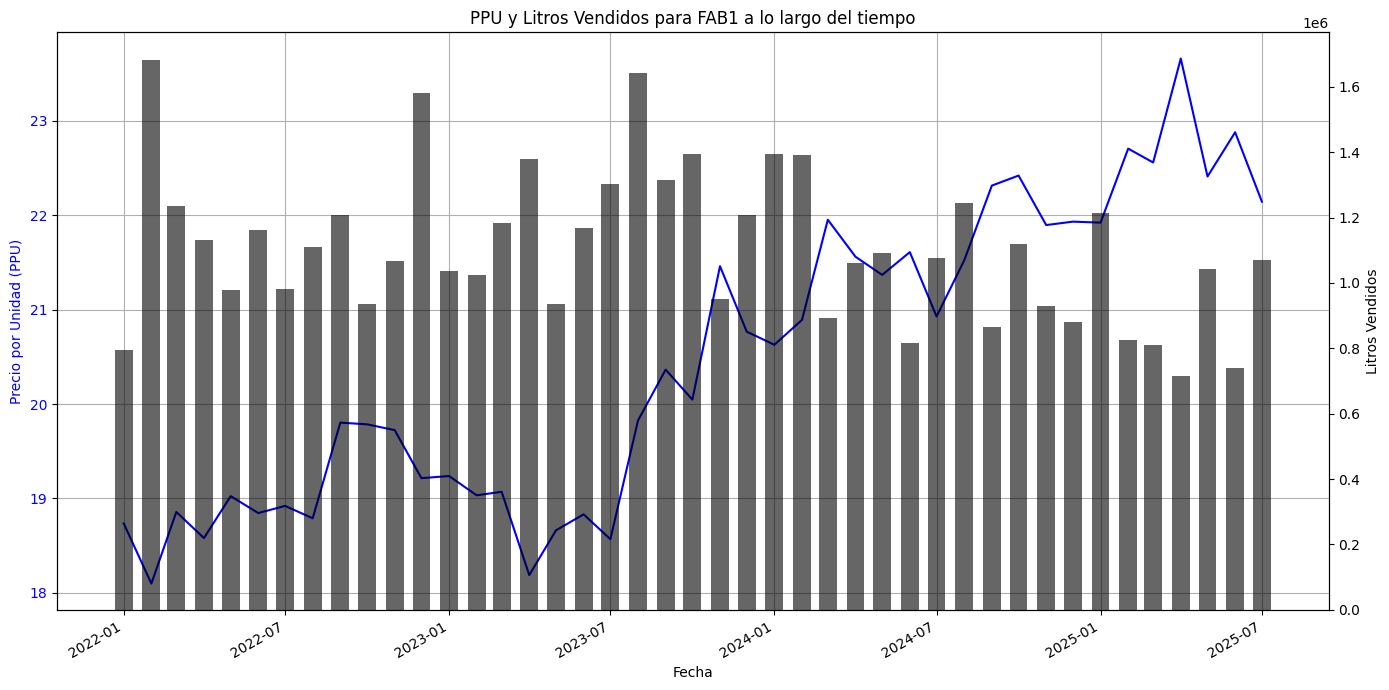

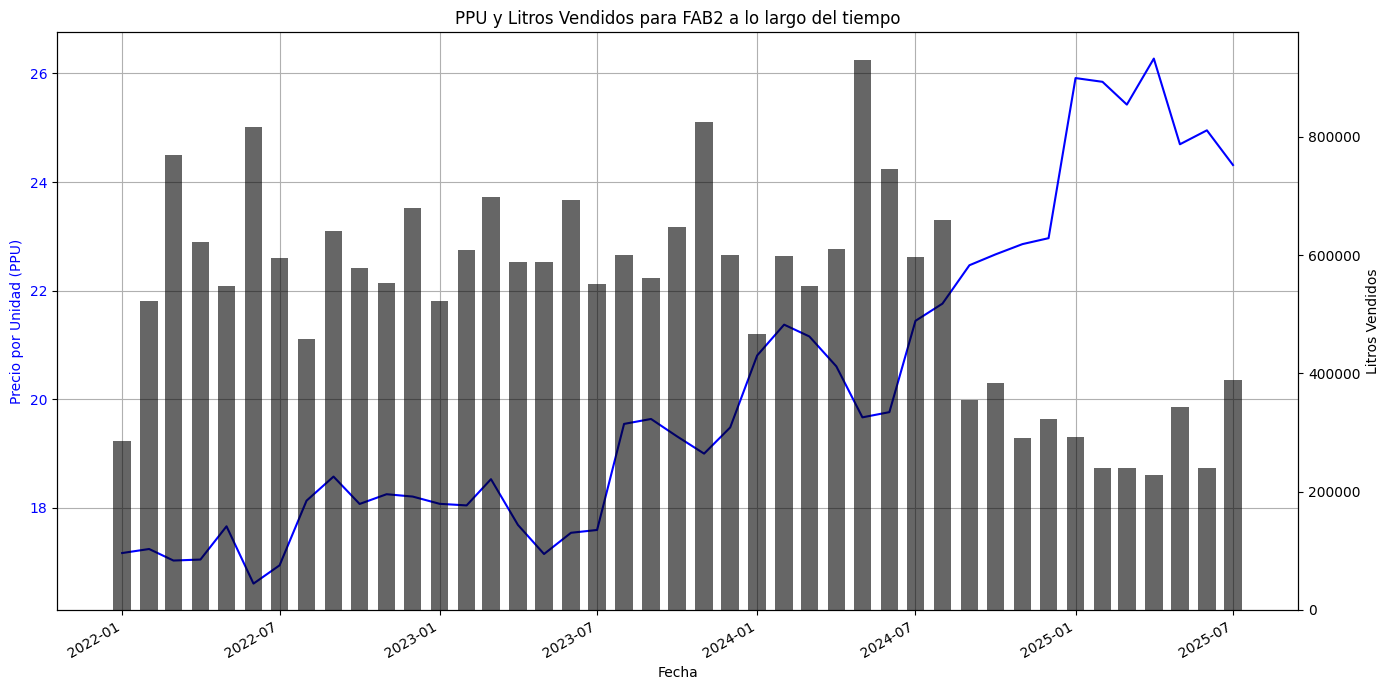

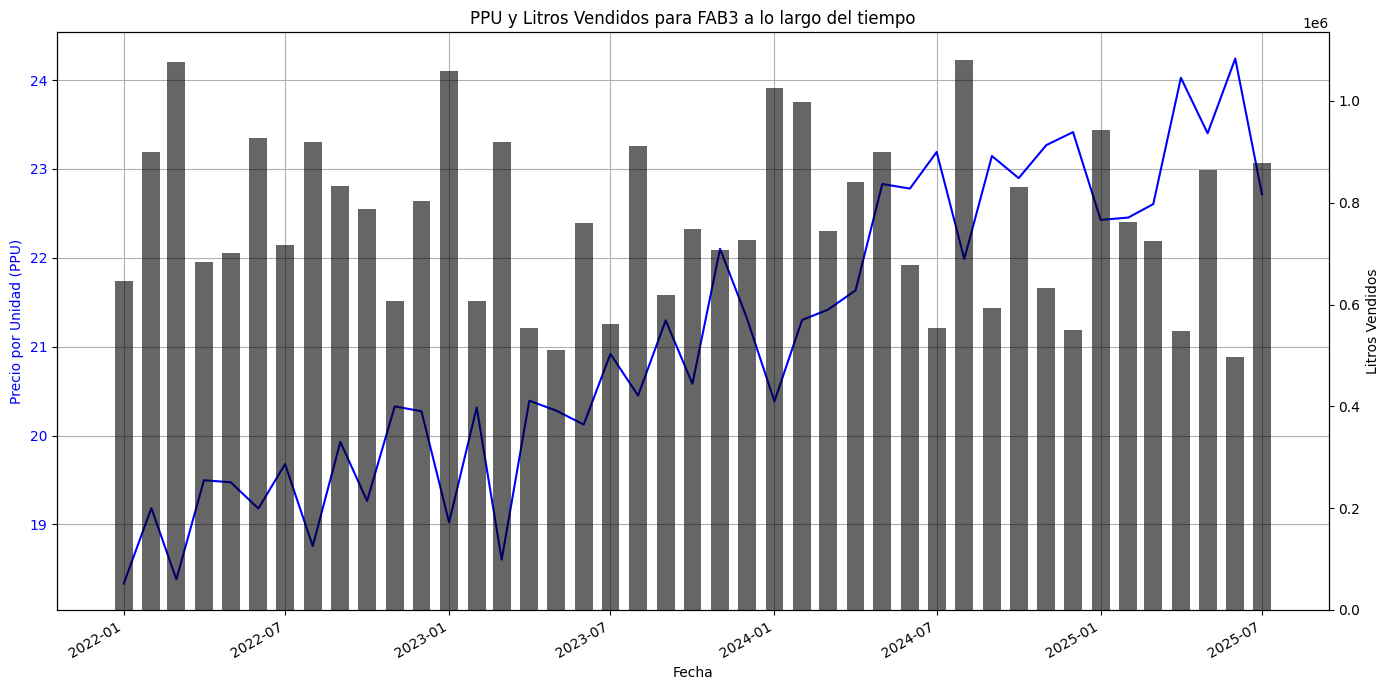

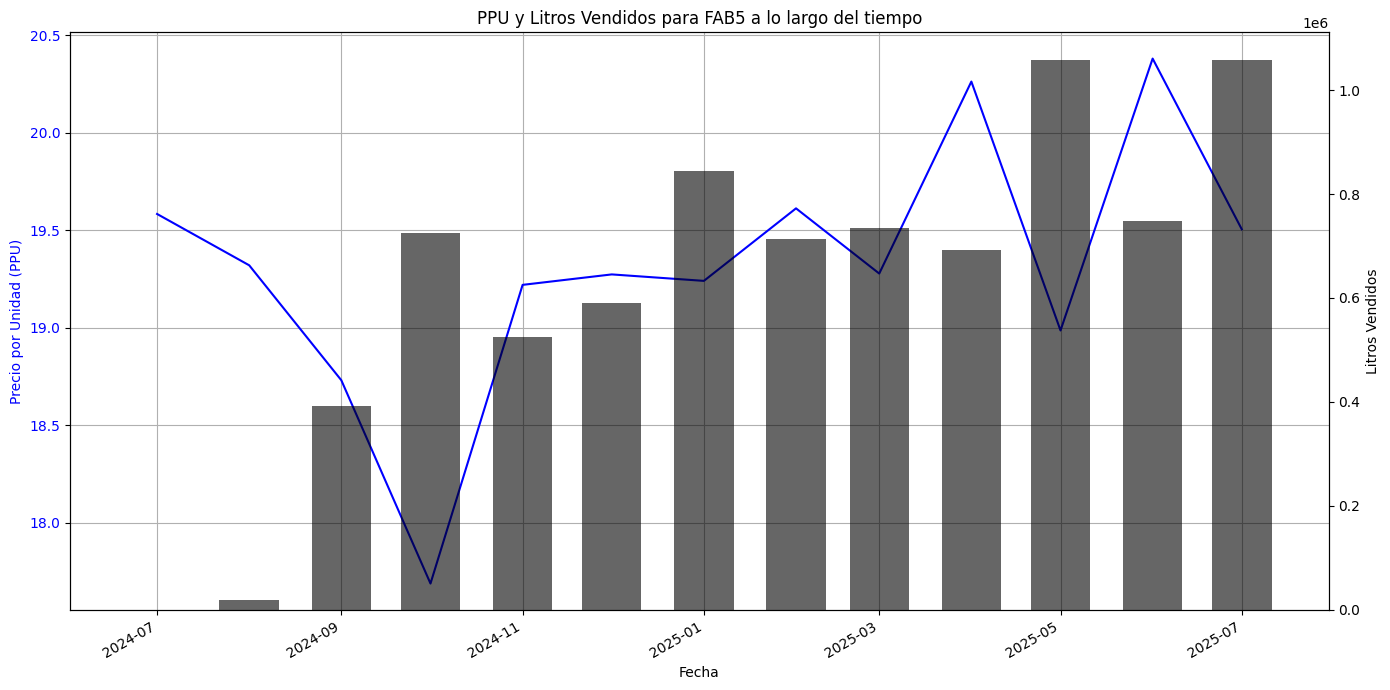

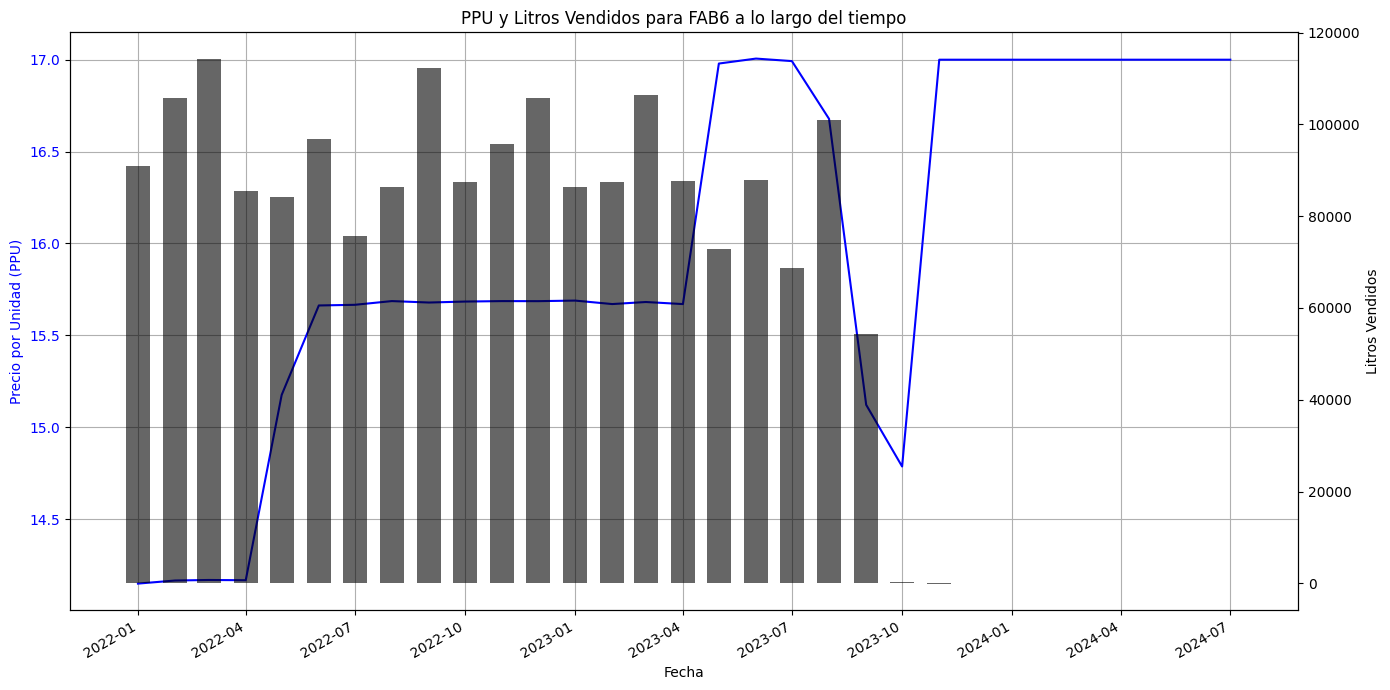

In [101]:
for _ , fabricante in enumerate(fab_historico['FABRICANTE'].unique()):

  fab = fab_historico[
      fab_historico['FABRICANTE'] == fabricante
  ].copy()

  fig, ax1 = plt.subplots(figsize=(14, 7))

  # Plot PPU on the primary y-axis
  ax1.plot(fab['FECHAM'], fab['PPU_Litro'], color='blue', label='PPU')
  ax1.set_xlabel('Fecha')
  ax1.set_ylabel('Precio por Unidad (PPU)', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax1.grid(True)

  # Create a second y-axis for Units
  ax2 = ax1.twinx()
  ax2.bar(fab['FECHAM'], fab['LITROS'], color='black', alpha=0.6, width=20, label='Unidades Vendidas')
  ax2.set_ylabel('Litros Vendidos', color='black')
  ax2.tick_params(axis='y', labelcolor='black')

  plt.title(f'PPU y Litros Vendidos para {fabricante} a lo largo del tiempo')
  fig.autofmt_xdate() # Rotate x-axis labels for better readability
  plt.tight_layout()
  plt.show()

Observando la gráfica se obtiene las siguientes iterpretaciones:

1. Fabricante 1: Se puede observar que en el transcurso de los años se ha amntenido estable la venta de litros de los productos, sin importar el incremento de precio. En el último año ha disminuido la vente en sus periodos de picos (Inicio de año y mitad de año).

2. Fabricante 2: En el caso de este fabricante, se puede observar que ha existido una disminución de ventas en los últimos años. Observando que inició por Julio de 2024, se podría asumir que su market share fue consumido por los productos de Fabricante 5 ya que en esa fecha fue cuando ingresó al mercado. Esto no es una conclusión, sino observación a primera vista del mercado. También se analiza que actualmente es de todos los fabricantes el que tiene mayor precio, con un punto máximo de más de 26 pesos por unidad.

3. Fabricante 3: Para este fabricante se puede observar un comportamiento similar al de fabricante 1, se mantiene estable en el paso de los años.

4. Fabricante 5: Al ingresar al mercado, consiguió rápidamente fuerza y un buen lugar dentro de la categoría. Se puede observar que es estable y tiene venta significativa aun siendo el que menor precio se vende, teniendo como precio máximo de 20.25 pesos por unidad.

5. Fabricante 6: Este fabricante se observa que mantuvo estable su precio por un par de meses y como en los últimos meses estaba perdiendo fuerza.


# Análisis de Fabricante 1

In [102]:
fab1_l12m = monthly_l12m[
    monthly_l12m['FABRICANTE'] == 'FAB1'
]
product_sales = (
    fab1_l12m
    .groupby('PRODUCTO')['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)


product_share = (
    product_sales /
    product_sales.sum()
)

print(round(product_share,2))

PRODUCTO
FAB1_Leche Clasica Entera 1 L                86884751.93
FAB1_Leche Clasica Deslactosada 1 L          85006585.93
FAB1_Leche Clasica Deslactosada Light 1 L    42840184.80
FAB1_1L  Sele En Selecta Entera              25018869.71
FAB1_1L  Sel Des Deslactosada                13399351.83
FAB1_Leche Clasica Extra Deslactosada 1 L     1951755.38
FAB1_Leche Clasica Light 1 L                   268755.67
FAB1_Leche Clasica Semi 1 L                     21450.00
Name: VENTA_VALOR, dtype: float64
PRODUCTO
FAB1_Leche Clasica Entera 1 L                0.34
FAB1_Leche Clasica Deslactosada 1 L          0.33
FAB1_Leche Clasica Deslactosada Light 1 L    0.17
FAB1_1L  Sele En Selecta Entera              0.10
FAB1_1L  Sel Des Deslactosada                0.05
FAB1_Leche Clasica Extra Deslactosada 1 L    0.01
FAB1_Leche Clasica Light 1 L                 0.00
FAB1_Leche Clasica Semi 1 L                  0.00
Name: VENTA_VALOR, dtype: float64


Analizando los productos de Fabricante 1, sus dos productos principales son la leche clasica entera y leche clasica deslactosada. Aunque ambos son muy parecidos y tienen un porcentaje bastante similar, se realizará un modelo de regresión lineal para el producto con mayor número de ventas, el cual es Leche Clasica Entera 1 L. Se buscará analizar y observar la elasticidad del producto y su relación respecto al volumen.

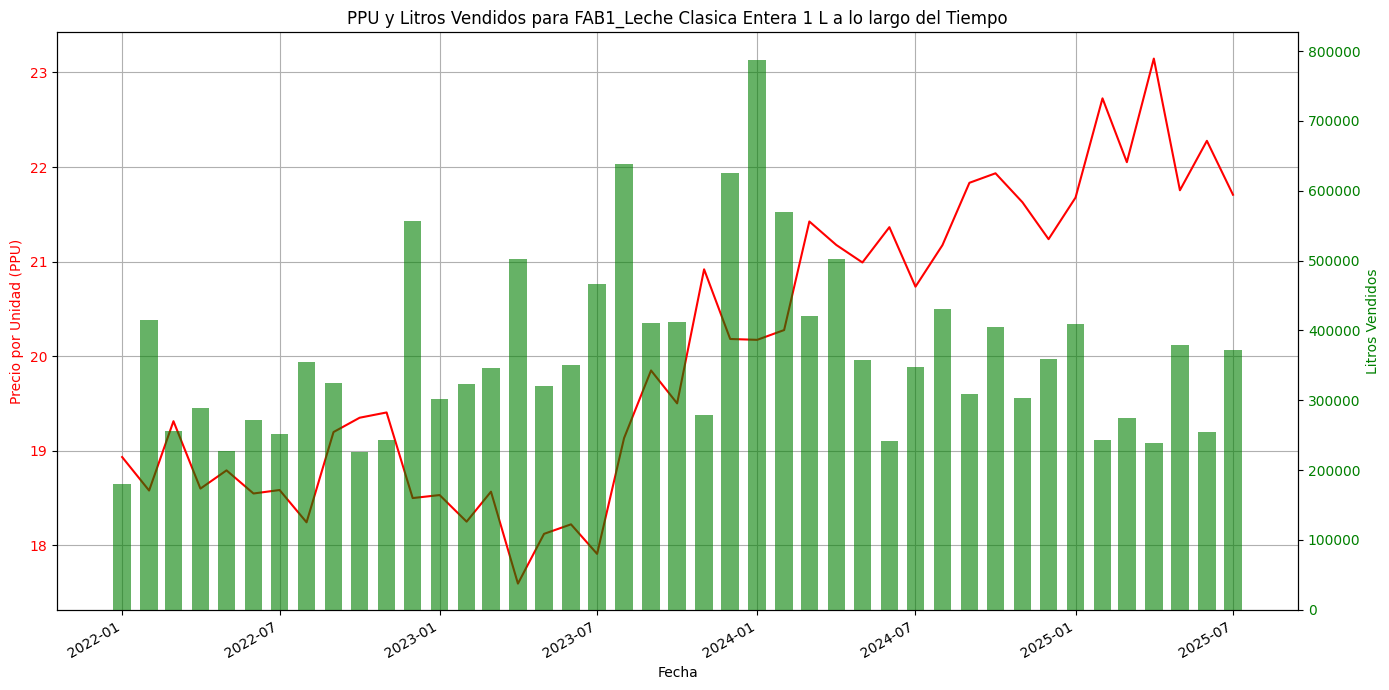

In [103]:
producto = 'FAB1_Leche Clasica Entera 1 L'

top_product = monthly[
    monthly['PRODUCTO'] == producto
].copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot PPU on the primary y-axis
ax1.plot(top_product['FECHAM'], top_product['PPU_Litro'], color='red', label='PPU')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio por Unidad (PPU)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)

# Create a second y-axis for Units
ax2 = ax1.twinx()
ax2.bar(top_product['FECHAM'], top_product['LITROS'], color='green', alpha=0.6, width=20, label='Unidades Vendidas')
ax2.set_ylabel('Litros Vendidos', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('PPU y Litros Vendidos para FAB1_Leche Clasica Entera 1 L a lo largo del Tiempo')
fig.autofmt_xdate() # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Realizando una gráfica que indican los litros y el precio unitario a través del tiempo, inicialmente se puede observar que el producto puede llegar a tener patrones estacionales, como se puede observar en fin de año que se despunta la venta de unidades y existe un incremento que no puede solo ser asociado al precio de venta.


In [119]:
# Correlaciones de volumen con el producto objetivo
corr_target_volumen = correlacion_volumen[target_product].sort_values(
    ascending=False
)

display(corr_target_volumen)

,FAB1_Leche Clasica Entera 1 L
PRODUCTO,
FAB1_Leche Clasica Entera 1 L,1.000000
FAB3_1L Desl Deslactosada,0.378068
FAB1_Leche Clasica Deslactosada 1 L,0.278105
FAB3_1L Ent Entera,0.223577
FAB1_Leche Clasica Deslactosada Light 1 L,0.110768
FAB2_ Deslac Deslactosada 1 L,0.106530
FAB5_Mm 12/1L Leche Ente Members Mark,-0.095363
FAB5_Mm 12/1L Leche Desla Members Mark,-0.147685


Realizando una correlación de volumen entre los productos top y el producto a predecir, se observa que si llega a existir una relación, principalmente entre el Fabricante 3 de leche deslactosada con un valor de 0.37 y seguido por la leche deslactosada del mismo fabricante que el producto a predecir. Esto es importante para observar debido al comportamiento entre productos y lo mucho que puede afectar el aumento de venta entre productos.

# Regresión Lineal de una variable


Para observar la elasticidad del modelo, se realizará el modelo en dos versiones, una es utilizando los coeficientes de manera natural, como vienen estructuradas en el dataset, y otra versión será utilizarla en su versión logarítmica.

De esta forma, se obtendrá la diferencia de forma porcentual, mientras que en el caso de coeficientes naturales se podrá observar cuanto volumen aumenta o disminuye.

## Version Lineal de regresión

In [104]:
import statsmodels.api as sm

X = top_product['PPU_Litro']
y = top_product['LITROS']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 LITROS   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.3721
Date:                Sat, 12 Sep 2026   Prob (F-statistic):              0.545
Time:                        04:04:15   Log-Likelihood:                -565.82
No. Observations:                  43   AIC:                             1136.
Df Residuals:                      41   BIC:                             1139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.248e+05    2.6e+05      2.021      0.0

Observando los resultados de la regresión lineal, se determina que el precio explica el 0.9% del volumen.

Analizando la predicción del modelo, se observa que el precio por litro indica que, cada peso que aumenta de precio, se estimaría una caída de  7,877 litros. También observando el estadístico t, se observa que el Precio por litro se encuentra a 0.61 desviaciones a la izquierda del valor hipótetico y un p-value de 0.545. Con esto se determina que, con la información del dataset, no se encuentra evidencia estadística significativa de una relación entre el precio y los litros vendidos.

## Versión logarítmica de regresión

In [105]:
top_product['log_litros'] = np.log(top_product['LITROS'])
top_product['log_ppu'] = np.log(top_product['PPU_Litro'])


X = top_product['log_ppu']
y = top_product['log_litros']

X = sm.add_constant(X)

elasticity_model = sm.OLS(y, X).fit()

print(elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_litros   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.2848
Date:                Sat, 12 Sep 2026   Prob (F-statistic):              0.596
Time:                        04:04:15   Log-Likelihood:                -11.504
No. Observations:                  43   AIC:                             27.01
Df Residuals:                      41   BIC:                             30.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8079      1.964      7.032      0.0

Analizando el modelo logarítmico, se observa que el precio del producto casi no explica el volumen de venta. Esto al tener un $R^2$ de 0.007 determina que tiene una relación prácticamente nula.


El coeficiente del PPU nos indica que si el precio unitario del producto sube un porciento, la venta en litros se reduce un 0.34%. Observando un estadístico t de -0.534 y un p-value con un valor de 0.59, se determina que no se puede rechazar la hipotesis nula, que se define como que no existe una relación entre el precio y volumen. Esto va acorde a los resultados obtenidos en el modelo anterior.

También al observar que el valor de $|β_1| < 1$ se determina que, para el modelo, la demanda es inelástica. Es decir, que el volumen no se mueve proporcionalmente a lo que indica el precio del producto.

Al analizar el intervalo de confianza, se puede observar que este está entre [-1.673, 0.974]. Esto significa que no se puede determinar que la elasticidad sea negativa y que afecte de manera activa al volumen.

Analizando el valor de Durbin Watson, el cual ayuda a determinar si existe autocorrelación, se obtiene un valor de 1.289. Esto sugiere que existe una autocorrelación positiva en los residuos.

Aunque los modelos no sean los más efectivos, esto puede ser por la falta de más variables importantes, esto siendo llamado **variable omitida**. Esto se refiere a que se busca explicar toda la variabilidad del volumen utilizando solo el precio, cuando existen otros factores que pueden afectar y el hecho de no tener otra variable que ayude a explicar el volumen, hace que el precio no se pueda explicar de buena manera.

Ahora, sabiendo esto, se buscaría crear ua seria de modelos que permitan analizar con mayor profundidad este problema y observar sus cambios respecto a cada variable.






#Regresión Multivariable

Como es un contexto de mundo real, el precio no es el único factor que puede influir en el volumen vendido o en la demanda de litros en este caso.

Se puede relacionar también con promociones, relación entre los productos de competencia o incluso con un producto de la misma empresa, temporalidades, factores macro económicos, entre otros.

Para aumentar la explicatividad y relación respecto al modelo anterior, se implementarán regresiones log-log con aumento de variables de forma progresiva. Para esto, se realizarán 3 modelos:

1. Modelo con tendencia temporal.

Inicialmente, se buscará agregar una variable que permita capturar si existe una tendencia temporal. Se incluye ya que, en caso de que si exista una tendencia creciente en las ventas, se puede capturar de mejor forma la relevancia de la elasticidad y que no sea sesgado por la variable omitida, así como se observó en el primer modelo. Para este se propone el siguiente modelo:

$\ln(Q_t)=\alpha+\beta\ln(P_t)+\tau T_t+\varepsilon_t$

* $Q_t$ determina el volumen vendido para el periodo t (Var. Dependiente).
* $P_t$ determina el precio del producto, así como en el modelo anterior.
* $T_t$ determina la tendencia temporal (**Variable incoporada**).
* β es el coeficiente para el precio, el cual determina el porcentaje de cambio, es decir, la elasticidad del producto.
* τ es el cambio de volumen con el paso del tiempo.
* ɛ representa el término de error.

Al incluir $T_t$ se puede separar la variación que estaba asociada al precio y así implementando una evolución temporal con el paso del tiempo.

2. Modelo con Estacionalidad Mensual

El segundo modelo busca agregar variables indicadoras de cada mes del año. Esto es para observar el comportamiento del modelo al buscar tendencias mensuales, buscando capturar factores estacionales, promociones recurrentes, hábitos de consumo, fechas especiales o características temporales de este mercado.


La estructura del modelo mencionado será la siguiente:


$\ln(Q_t)=\alpha+\beta\ln(P_t)+\tau T_t +\sum_{m=2}^{12}\delta_m D_{mt}+\varepsilon_t$

La diferencia del modelo anterior, es que se busca incorporar $D_{mt}$, los cuales son variables *"dummy"* que toman valores 1 cuando la observación corresponde a su respectivo mes y 0 en el caso contrario. Un mes se pone como "referencia" con el objetivo de evitar una multicolinealidad perfecta y así funcionar como la variable base.

El coeficiente $δ_m$ es para representar la diferencia en el nivel esperado de venta en ese mes respecto al mes de referencia.

Se busca encontrar y estimar el aumento o disminución de volumen de cada mes con el objetivo de encontrar diferencias relevantes entre los meses del año. De esta manera también se reduce el error y permite que este efecto no quede mezclado con el del precio.

3. Modelo con precios de competencia y elasticidad cruzada

Como último modelo, se quiere incluir información sobre los productos principales y competidores del mercado. Esto es para principalmente encontrar una relación objetiva entre estos productos y encontrar lo que se llama una **"Elasticidad Cruzada"**. El objetivo es observar que tanto afecta el cambio de precio de un producto de competencia y que tanto beneficia o afecta la venta del prodcuto a predecir.

El modelo se vería de la siguiente manera.


$\alpha+\beta\ln(P_t)+\sum_{m=2}^{12}\delta_mD_{mt}+\tau T_t+\sum_{j=1}^{k}γ_j\ln(P_{jt})+\varepsilon_t$

* $P_{jt}$ se determina como el precio del competidor *j* en un tiempo *t*
* $γ_j$ representa la elasticidad cruzada respecto al precio del competidor *j*.


Con el uso de $γ_j$, se podrá observar el coeficiente de elasticidad cruzada de cada producto competencia a comparación de la que se busca predecir.

# 1. Versión logarítmica multivariada (estacionalidad)

In [106]:
reg_season = top_product.copy()
reg_season = reg_season.sort_values('FECHAM').copy()

reg_season = reg_season[
    (reg_season['LITROS'] > 0) &
    (reg_season['PPU_Litro'] > 0)
].copy()

# Transformaciones logarítmicas
reg_season['log_LITROS'] = np.log(reg_season['LITROS'])
reg_season['log_PPU'] = np.log(reg_season['PPU_Litro'])

# Crear variables dummy para los meses
reg_season = pd.get_dummies(
    reg_season,
    columns=['MES'],
    drop_first=True,
    dtype=int
)

y_season = reg_season['log_LITROS']
month_dummies = [
    col for col in reg_season.columns
    if col.startswith('MES_')
]

X_season = reg_season[['log_PPU'] + month_dummies]

# Agregar intercepto
X_season = sm.add_constant(X_season)

# Asegurar que todas las variables sean numéricas
X_season = X_season.astype(float)
y_season = y_season.astype(float)


# Modelo log-log con estacionalidad
model_season = sm.OLS(y_season, X_season).fit()

print(model_season.summary())



                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                 -0.039
Method:                 Least Squares   F-statistic:                    0.8695
Date:                Sat, 12 Sep 2026   Prob (F-statistic):              0.584
Time:                        04:04:16   Log-Likelihood:                -5.2363
No. Observations:                  43   AIC:                             36.47
Df Residuals:                      30   BIC:                             59.37
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.1725      2.019      6.524      0.0

Por funcionamiento de la función "get.dummies" de Python, escoge la variable categórica más pequeña y así se determina que la variable de referencia es Enero.


Interpretando el resultado de este modelo de regresión multivariada, el cual ya incluye el precio del producto junto con la estacionalidad, se puede observar que la $R^2$ aumentó a 0.258, aunque no llega a ser práctico debido a que se tiene un R ajustada de -0.039.

Observando el coeficiente de elasticidad, se observa que $β_1 = -0.1235$, lo cual nos da a entender que si aumenta 1% de precio, se disminuye aproximadamente 0.124% de litros de venta. Se sigue observando que $|β_1| < 1$, por lo que se sigue determinando que es una demanda inelástica. Al tener un p-value de 0.856, se concluye que no existe evidencia estadísticamente significativa para decir que el precio tiene un efecto distinto a 0 sobre los litros vendidos. A comparación del modelo anterior, se observa que el p-value ha aumentado y el intervalo de confianza es aún más amplio y todavía cubre el 0. Esto nos da a entender que se tiene cierta incertidumbre sobre el efecto de precio respecto a este producto.

Observando el cambio al agregar las estacionalidades, se observa que se distribuye la variación a los meses del año y eso permite que el coeficiente de $β_1$ se pueda explicar de una mejor manera, al no atribuirse valores que pueden esta relacionados a comportamientos estacionales.

# 2. Regresión multivariada (estacionalidad + tendencia)

In [107]:
reg_season = reg_season.sort_values('FECHAM').copy()

# Crear tendencia temporal
reg_season['trend'] = np.arange(len(reg_season))

# Variable dependiente
y_trend = reg_season['log_LITROS']

# Variables de estacionalidad
month_dummies = [
    col for col in reg_season.columns
    if col.startswith('MES_')
]

X_trend = reg_season[['log_PPU', 'trend'] + month_dummies]


X_trend = sm.add_constant(X_trend)


X_trend = X_trend.astype(float)
y_trend = y_trend.astype(float)

# Ejecutar modelo
model_trend = sm.OLS(y_trend, X_trend).fit()

print(model_trend.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     1.990
Date:                Sat, 12 Sep 2026   Prob (F-statistic):             0.0604
Time:                        04:04:16   Log-Likelihood:                 2.0559
No. Observations:                  43   AIC:                             23.89
Df Residuals:                      29   BIC:                             48.54
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.1850      3.655      6.617      0.0

Al agregar una tendencia de crecimiento al modelo, hubo un cambio drástico respecto a la explicabilidad del modelo.

Se observa que la $R^2$ aumentó a un 0.471 y su R ajustada a un 0.235. Esto demuestra que al agregar esta variable, se mejoró a comparación de los anteriores.

Analizando la elasticidad, el modelo muestra un coeficiente negativo de -3.9698, lo cual indica que un aumento de 1% de precio está asociado a una disminución aproximada de 3.97% de venta de litros. Comparando con el modelo anterior, se observa que hubo un cambio de elasticidad estimada de -0.35 a -3.9698, el cual es aproximadamente once veces mayor en magnitud. También se observa que este modelo si muestra significancia estadística al tener un p-value menor a 0.05 y da evidencia estadísticamente significativa de que el producto si tiene una relación negativa respecto al producto. Cabe mencionar que el intervalo de confianza está entre [-6.555, -1.384], lo cual demuestra que se mentiene en un rango negativo y reafirma la suposición de tener relación negativa respecto al producto.

Todo esto ayuda a reafirmar que el modelo estaba omitiendo una variable importante de variación temporal. Al controlar este factor, la variación que antes era también atribuida a la variable de precio ya es separada de una mejor manera y deja observar una relación de precio volumen más clara.

Analizando la variable de tendencia, se observa que el crecimiento promedio es aproximadamente de 2.61% por cada periodo mensual. Al tener un p-value de 0.002, se reafirma que el producto sigue una tendencia de crecimiento que los modelos anteriores no podían controlar de manera adecuada.

Respecto a la estacionalidad, se observa que no tienen evidencia estadísticamente significativa para demostrar que existen diferencias entre los meses y enero. Cabe mencionar que no significa que no exista diferencia entre los meses, simplemente con la información obtenida no se ha encontrado evidencia significativa para identificar estos meses individualmente con precisión.

Ahora, analizando el estadístico Durbin-Watson, se mantiene cercano a 1.1, lo cual se podría determinar que el calculo que realiza el modelo es poco confiable. Para corregir esto se buscaría utilizar otro método de errores estándar, el cual es HAC. Este busca ajustar los errores estándar para que sean más confiables cuando los residuos presentan autocorrelación. Esto puede llegar a afectar el cálculo de estadísticos como el estadístico t, p-value y los intervalos de confianza.

In [108]:
# Modelo con errores estándar HAC
model_trend_hac = model_trend.get_robustcov_results(
    cov_type='HAC',
    maxlags=1
)

print(model_trend_hac.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     7.343
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           4.40e-06
Time:                        04:04:16   Log-Likelihood:                 2.0559
No. Observations:                  43   AIC:                             23.89
Df Residuals:                      29   BIC:                             48.54
Df Model:                          13                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.1850      2.703      8.946      0.0

Para esta prueba, se utiliza un máximo de 1 lag ya que permite que tome en cuenta la relación entre el error de un mes y el mes anterior. Al ser solo 43 observaciones, tener un solo lag es adecuado. También no es algo realista que un error de hace dos meses afecte el de el mes actual. En caso de ser semanal, se podrían considerar una mayor cantidad.


Ahora, analizando los cambios, se modifica la estimación de las variables. En este caso, para el precio se obtiene un error estándar de HAC de 0.920, un estadístico t de -4.313 y un p-value menor a 0.001, de esta manera se puede observar que, incluso al corregir la inferencia por posible autocorrelación, se mantiene la evidencia estadísticamente significativa de la relación negativa entre precio y volumen.

## Variante incluyendo semanas por mes

Con el objetivo de ser más detallados, se busca incorporar el número de semanas que tiene cada mes con el objetivo de capturar la relación que tiene los meses que incluyen una semana más. Esto es importante de observar ya que una semana de venta puede llegar a tener una variación relevante entre un mes y otro.


De esta manera, el modelo ya incluye una relación logarítmica de el número de semanas, el cual permite observar la elasticidad de volumen al número de semanas que contiene el mes.

In [109]:
semanas_mes = (
    df.groupby('FECHAM')['FECHAW']
      .nunique()
      .reset_index(name='N_SEMANAS')
)

reg_season = reg_season.merge(
    semanas_mes,
    on='FECHAM',
    how='left'
)

reg_season['log_N_SEMANAS'] = np.log(reg_season['N_SEMANAS'])


X_semanas = reg_season[
    ['log_PPU', 'trend', 'log_N_SEMANAS'] + month_dummies
]

X_semanas = sm.add_constant(X_semanas)
X_semanas = X_semanas.astype(float)

y_semanas = reg_season['log_LITROS'].astype(float)

model_semanas = sm.OLS(y_semanas, X_semanas).fit()

model_semanas_hac = model_semanas.get_robustcov_results(
    cov_type='HAC',
    maxlags=1
)

print(model_semanas_hac.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     11.43
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           4.19e-08
Time:                        04:04:16   Log-Likelihood:                 4.1688
No. Observations:                  43   AIC:                             21.66
Df Residuals:                      28   BIC:                             48.08
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            22.9985      2.605      8.830

Observando los resultados, se interpreta que el número de semanas si afecta. Al tener un incremento de 1% en el número de semanas, se incrementa un 0.71% de venta de litros de producto. También se puede observar que tiene un error estándar bajo y que nuestra variable está a 3 desviaciones estándar de distancia, así obteniendo un p-value menor a 0.05 y determinado que se tiene evidencia estadísticamente significativa para determinar que si hay una relación entre el número de semanas con la venta de producto.

# 3. Regresión Multivariada (estacionalidad + tendencia + competencia)


Una vez realizados los modelos anteriores, se buscaría hacer un modelo que incluya también los productos competencia, esto con el objetivo de observar una elasticidad cruzada y si afecta mucho el precio de otros productos a la venta de litros de nuestro producto principal.

In [110]:
# Producto objetivo
target_product = 'FAB1_Leche Clasica Entera 1 L'

# Competidores = productos top
competidores = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB5_Mm 12/1L Leche Ente Members Mark',
    'FAB3_1L  Desl Deslactosada',
    'FAB5_Mm 12/1L Leche Desla Members Mark',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]

In [111]:
# Filtrar productos objetivo + competidores
productos_modelo = [target_product] + competidores

df_modelo = monthly[
    monthly['PRODUCTO'].isin(productos_modelo)
].copy()

df_modelo = df_modelo.sort_values('FECHAM')

precios = df_modelo.pivot_table(
    index='FECHAM',
    columns='PRODUCTO',
    values='PPU_Litro',
    aggfunc='mean'
)

precios = precios.reset_index()
volumen = df_modelo[
    df_modelo['PRODUCTO'] == target_product
][['FECHAM', 'LITROS']].copy()

volumen = volumen.rename(
    columns={'LITROS': 'LITROS_TARGET'}
)

reg_comp = volumen.merge(
    precios,
    on='FECHAM',
    how='inner'
)

reg_comp = reg_comp.sort_values('FECHAM').copy()

reg_comp.head(35)

,FECHAM,LITROS_TARGET,FAB1_Leche Clasica Deslactosada 1 L,FAB1_Leche Clasica Deslactosada Light 1 L,FAB1_Leche Clasica Entera 1 L,FAB2_ Deslac Deslactosada 1 L,FAB3_1L Desl Deslactosada,FAB3_1L Ent Entera,FAB5_Mm 12/1L Leche Desla Members Mark,FAB5_Mm 12/1L Leche Ente Members Mark
0,2022-01-01,179628,17.894349,19.473101,18.933136,16.979174,18.624347,18.158429,NaN,NaN
1,2022-02-01,414468,16.954899,18.814841,18.578916,17.445016,19.400232,18.989434,NaN,NaN
2,2022-03-01,255948,17.885441,19.449479,19.312209,17.260064,18.787825,18.171513,NaN,NaN
3,2022-04-01,288564,17.845226,19.359474,18.599331,17.447897,20.004713,19.232643,NaN,NaN
4,2022-05-01,227664,18.782089,19.258161,18.792112,17.895156,19.797694,19.240419,NaN,NaN
5,2022-06-01,271176,18.813538,18.955294,18.547633,16.808192,19.528229,18.928353,NaN,NaN
6,2022-07-01,252108,18.788449,19.063637,18.584326,16.976531,20.066849,19.383002,NaN,NaN
7,2022-08-01,354252,18.796803,19.144642,18.242792,18.211054,18.990431,18.578119,NaN,NaN
8,2022-09-01,325308,19.461670,20.316775,19.197450,18.736484,19.668355,19.932079,NaN,NaN
9,2022-10-01,226236,19.750714,19.862350,19.348883,18.221290,19.411917,19.024303,NaN,NaN


Observando los productos de Fabricante 5, se observa que no existe información hasta Agosto de 2024.

En este contexto se pueden realizar dos cosas.

1. Reducir la información de Agosto de 2024 en adelante para capturar los precios de todos los productos competencia en los últimos 12 meses.
2. Excluirlos de la regresión multivariada.


En este caso, al darle prioridad al histórico, se eliminan estas dos columnas del dataset para permitir el uso de todo el histórico disponible. Cabe mencionar que esto afectará el desempeño y relación del modelo, ya que estas dos variables pueden están siendo relevantes en la actualidad.

In [112]:
reg_comp = reg_comp.drop(['FAB5_Mm 12/1L Leche Desla Members Mark', 'FAB5_Mm 12/1L Leche Ente Members Mark'], axis=1)
reg_comp

,FECHAM,LITROS_TARGET,FAB1_Leche Clasica Deslactosada 1 L,FAB1_Leche Clasica Deslactosada Light 1 L,FAB1_Leche Clasica Entera 1 L,FAB2_ Deslac Deslactosada 1 L,FAB3_1L Desl Deslactosada,FAB3_1L Ent Entera
0,2022-01-01,179628,17.894349,19.473101,18.933136,16.979174,18.624347,18.158429
1,2022-02-01,414468,16.954899,18.814841,18.578916,17.445016,19.400232,18.989434
2,2022-03-01,255948,17.885441,19.449479,19.312209,17.260064,18.787825,18.171513
3,2022-04-01,288564,17.845226,19.359474,18.599331,17.447897,20.004713,19.232643
4,2022-05-01,227664,18.782089,19.258161,18.792112,17.895156,19.797694,19.240419
5,2022-06-01,271176,18.813538,18.955294,18.547633,16.808192,19.528229,18.928353
6,2022-07-01,252108,18.788449,19.063637,18.584326,16.976531,20.066849,19.383002
7,2022-08-01,354252,18.796803,19.144642,18.242792,18.211054,18.990431,18.578119
8,2022-09-01,325308,19.461670,20.316775,19.197450,18.736484,19.668355,19.932079
9,2022-10-01,226236,19.750714,19.862350,19.348883,18.221290,19.411917,19.024303


In [113]:
competidores = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB3_1L  Desl Deslactosada',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]

productos_modelo = [target_product] + competidores


reg_comp = reg_comp[
    reg_comp['LITROS_TARGET'] > 0
].copy()

reg_comp['log_LITROS'] = np.log(
    reg_comp['LITROS_TARGET']
)

for p in productos_modelo:
    reg_comp[f'log_P_{p}'] = np.log(
        reg_comp[p]
    )

In [114]:
#Tendencia
reg_comp['trend'] = np.arange(len(reg_comp))

#Variable de precio
precio_vars = [
    f'log_P_{p}'
    for p in productos_modelo
]
# Variables de precio
X_comp = reg_comp[precio_vars + ['trend']].copy()

# variables dummy de mes
reg_comp['MES'] = reg_comp['FECHAM'].dt.month
reg_comp = pd.get_dummies(
    reg_comp,
    columns=['MES'],
    drop_first=True,
    dtype=int
)

month_dummies = [
    col for col in reg_comp.columns
    if col.startswith('MES_')
]

X_comp = reg_comp[
    precio_vars + ['trend'] + month_dummies
]

X_comp = sm.add_constant(X_comp).astype(float)

y_comp = reg_comp['log_LITROS'].astype(float)

#Modelo
model_comp = sm.OLS(
    y_comp,
    X_comp
).fit()

print(model_comp.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     1.237
Date:                Sat, 12 Sep 2026   Prob (F-statistic):              0.309
Time:                        04:04:16   Log-Likelihood:                 2.4561
No. Observations:                  43   AIC:                             33.09
Df Residuals:                      24   BIC:                             66.55
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

Para el modelo que incluye los productos top se observa un cambio respecto a la elasticidad del producto.
La variable de precio de nuestro producto principal se ve afectado respecto a su evidencia estadística y su coeficiente.

Aumentó a -4.1488, lo cual indica que un aumento de 1% de precio se predice a una disminución aproximada de 4.15% de venta de litros. Ahora, no se puede afirmar que esta elasticidad sea estadísticamente significativa ya que el p-value es de 0.178 y el intervalo de confianza nuevamente contiene a cero.

Observando los PPU's de los demás productos, se observa que algunos son de coeficiente positivo y otros negativo. También se puede observar que su p-value es mayor a 0.5, lo cual nos indica que ninguno tiene evidencia estadística para demostrar que su cambio de precio afecta la demanda de nuestro producto.


Una posible explicación sobre la pérdida de significancia en el modelo es la multicolinealidad entre los precios. Esto tiene sentido ya que se ha agregado productos que coexisten de una forma similar. Es decir, al tener productos que son del mismo fabricante, tienen un comportamiento bastante similar. Incluso generalizando esta categoría, se esperaría que los precios de los productos que pelean en una misma categoría tengan movimientos relacionados.


Observando el modelo en general, se tiene un $R^2$ de 0.48 y un R ajustado de 0.092. A comparación del modelo anterior, no ha mejorado la explicabilidad del modelo al observar la disminución de R ajustada.

Así como el modelo anterior, se buscará analizar los estadísticos en base a HAC con le objetivo de encontrar resultados con una inferencia de posible heterocedasticidad.

In [115]:
model_comp_hac = model_comp.get_robustcov_results(
    cov_type='HAC',
    maxlags=1
)

print(model_comp_hac.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     10.07
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           3.32e-07
Time:                        04:04:16   Log-Likelihood:                 2.4561
No. Observations:                  43   AIC:                             33.09
Df Residuals:                      24   BIC:                             66.55
Df Model:                          18                                         
Covariance Type:                  HAC                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

Observando los resultados se ha disminuido de forma ligera el error estándar y, consecuentemente, el estadístico t y p-value. Existe un cambio respecto al modelo anterior. La variable de tendencia se volvió estadísticamente significativa, pasando de un p=0.203 a p=0.023 con HAC. Esto permite determinar que HAC si cambió la inferencia de la tendencia en este modelo.

# Mejor modelo

Tras correr los modelos progresivos y analizar sus estadísticos, se observa que la incorporación de la tendencia temporal es la que mejora considerablemente la capacidad explicativa del modelo.

Ahora, al agregar el número de semanas por mes, el $R^2$ aumenta hasta un 0.521, teniendo un R ajustado de 0.281, por lo que la variable si aporta información adicional relevante.

Con esto se podría determinar que este ha sido el modelo que mejor ha explicado al volumen del producto.

Se pensaría que el modelo con productos de la competencia mejoraría el modelo, pero al tener una multicolinealidad bastante alta (La cual también se observa en la matriz de correlación) no permite identificar patrones y relaciones adecuadas para las variables para así tener una estimación adecuada para el precio del producto y así capturar su elasticidad.

# Predicción a futuro (24 meses)

Para poder predecir a futuro, se podría entender que un modelo de regresión puede ser adecuado, ya que permite observar los coeficientes que arroja el modelo y observar directamente que tanto afecta el aumento o disminución de alguna variable, como se observó anteriormente de los Precios y tendencias.


Ahora, algo que se considera importante es la relación tendencial en los meses acorde al producto. Existe una relevancia muy importante para los productos dependiendo de en que categoría compite y su estacionalidad con mayor relevancia. Un ejemplo para esto es como los chocolates tienen picos altos de venta en Febrero y Mayo, esto por el 14 de Febrero y el día de las madres, respectivamente.


Ahora, sabiendo esto y entendiendo que este es una serie de tiempo, se ha investigado sobre posibles modelos a implementar para este tipo de problemas.

Un ejemplo de estos es el modelo  ARIMA / SARIMA,
ARIMa busca la dependencia temporal y autocorrelación de la serie, mientras que SARIMA es la extensión de ARIMA, el cual permite incorporar estructuras estacionales.

Otro modelo que se ha encontrado es el VAR (Vector Autorregresivo) el cual busca encontrar relación y analizar variables que cambian y se afectan mutuamente, el cual podría ser el caso de la elasticidad cruzada o incluso la canibalización interna, el como un producto de mayor tamaño al reducir su precio podría afectar el producto a analizar. Este puede ser útil cuando varias series presentan una relación dinámica entre ellas.
Ahora, al tener solamente 43 observaciones mensuales, numerosas variables pueden generar un número elevado de parámetros a relación con el tamaño de la muestra, por lo cual no podriá ser óptimo.

Entrando más en concepto de Deep Learning, se podría utilizar una red neuronal que pueda encontrar patrones mucho más ocultos y no lineales entre los productos que permita predecir de una forma más especifica. Así como VAR, al tener una cantidad limitada de observaciones puede provocar un sobreajuste y que no capture de forma adecuada la relación con los datos.


Todos estos modelos podrían ser adecuados, pero también es importante considerar cual utilizar acorde a como se comporte la categoría, el producto y sus competidores.

Es importante mencionar que el modelo que sea seleccionado no se puede basar solamente en el ajuste dentro de la muestra, sino con la capacidad de generar pronósticos que son fuera de este. Es por eso que también debe ser acorde a las métricas de evaluación, asi como MAE, RMSE o MAPE.